<a href="https://colab.research.google.com/github/LiQuinChing/DL-fakeNewsClassification/blob/Vihara-BiLSTM/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Mount if needed:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ============================================
# LSTM Fake/Real News Classifier (Colab-ready)
# ============================================
import os, re, json, numpy as np, pandas as pd
from glob import glob

# --------- 1) Load all cleaned files ----------
BASE = "/content/drive/MyDrive"
DATA_ROOT = f"{BASE}/news_clean1"

# Globs that match your structure
paths_fnr = sorted(glob(os.path.join(DATA_ROOT, "fake_and_real", "**", "*.csv"), recursive=True))
paths_fake_mixed = sorted(glob(os.path.join(DATA_ROOT, "fake", "**", "*.csv"), recursive=True))
paths_real_only  = sorted(glob(os.path.join(DATA_ROOT, "real", "archive", "*.csv")))

def safe_read(path):
    # all cleaned files should already have title,text,label (except maybe real-only files)
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print("skip (read error):", path, e)
        return None
    # normalize columns
    cols = {c.lower().strip(): c for c in df.columns}
    # standardize to lower-case keys in a copy
    df.columns = [c.lower().strip() for c in df.columns]
    # keep only relevant if present
    keep = [c for c in ["title","text","label"] if c in df.columns]
    if not keep:
        print("skip (no expected columns):", path)
        return None
    df = df[keep].copy()
    # fill title if missing
    if "title" not in df.columns: df["title"] = ""
    # clean text/title
    def clean_ws(s):
        if pd.isna(s): return ""
        s = str(s).replace("\u201c",'"').replace("\u201d",'"').replace("\u2019","'")
        return re.sub(r"\s+", " ", s).strip()
    df["title"] = df["title"].map(clean_ws)
    df["text"]  = df["text"].map(clean_ws)
    # handle label presence per file-type outside this function
    return df

# Load fake_and_real two-file sets (already labeled 0/1 in previous cleaning)
dfs = []
for p in paths_fnr:
    df = safe_read(p)
    if df is None: continue
    # if label missing (shouldn't be), infer from filename
    if "label" not in df.columns:
        is_real = 1 if os.path.basename(p).lower().startswith("real") else 0
        df["label"] = is_real
    dfs.append(df)

# Load fake/** mixed (already labeled 0/1)
for p in paths_fake_mixed:
    df = safe_read(p)
    if df is None: continue
    # if label missing (rare), default to 0 because under /fake/
    if "label" not in df.columns:
        df["label"] = 0
    dfs.append(df)

# Load real/archive real-only files; force label=1 if missing
for p in paths_real_only:
    df = safe_read(p)
    if df is None: continue
    if "label" not in df.columns:
        df["label"] = 1
    else:
        # coerce any non-numeric/strings to 1 if they indicate real
        s = df["label"].astype(str).str.lower().str.strip()
        df.loc[~s.isin(["0","1","fake","real","false","true","no","yes","n","y"]), "label"] = 1
    dfs.append(df)

assert len(dfs) > 0, "No dataframes loaded — check your folder paths."

data = pd.concat(dfs, ignore_index=True)

# Keep only text + binary label
data = data.dropna(subset=["text", "label"]).copy()
# Map label to int 0/1 robustly
def to01(x):
    x = str(x).strip().lower()
    if x in ["1","real","true","yes","y"]: return 1
    if x in ["0","fake","false","no","n"]: return 0
    try:
        f = float(x)
        return 1 if f >= 0.5 else 0
    except:
        return np.nan
data["label"] = data["label"].map(to01)
data = data.dropna(subset=["label"])
data["label"] = data["label"].astype(int)

# Concatenate title → text for a small boost
data["text_full"] = np.where(
    data["title"].fillna("").str.len() > 0,
    data["title"].fillna("") + " . " + data["text"].fillna(""),
    data["text"].fillna("")
)

# Drop empty/very short
data = data[data["text_full"].str.len() >= 10].copy()
data = data.drop_duplicates(subset=["text_full"]).reset_index(drop=True)

print("Rows:", len(data), "| Positives (real=1):", int((data['label']==1).sum()))

# --------- 2) Train/Val/Test split ----------
from sklearn.model_selection import train_test_split
X_train, X_tmp, y_train, y_tmp = train_test_split(
    data["text_full"].values, data["label"].values,
    test_size=0.2, random_state=42, stratify=data["label"].values
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp
)

# --------- 3) Tokenize ----------
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 60000   # vocab size
MAX_LEN   = 400     # sequence length

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

def to_seq(texts):
    return pad_sequences(tokenizer.texts_to_sequences(texts), maxlen=MAX_LEN, padding="post", truncating="post")

X_train_seq = to_seq(X_train)
X_val_seq   = to_seq(X_val)
X_test_seq  = to_seq(X_test)

# Save tokenizer for reuse
tok_dir = f"{BASE}/news_models"
os.makedirs(tok_dir, exist_ok=True)
with open(os.path.join(tok_dir, "tokenizer.json"), "w") as f:
    f.write(tokenizer.to_json())

# --------- 4) Class weights (help if imbalanced) ----------
from sklearn.utils.class_weight import compute_class_weight
classes = np.array([0,1])
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {0: float(cw[0]), 1: float(cw[1])}
print("Class weight:", class_weight)

# --------- 5) Build model ----------
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

def build_bilstm(max_words=MAX_WORDS, max_len=MAX_LEN):
    inp = layers.Input(shape=(max_len,))
    x = layers.Embedding(input_dim=max_words, output_dim=128, input_length=max_len)(inp)
    x = layers.SpatialDropout1D(0.2)(x)
    x = layers.Bidirectional(layers.LSTM(96, return_sequences=True))(x)
    # Combine last hidden state & pooled features (often stronger than either alone)
    last = layers.Lambda(lambda t: t[:, -1, :])(x)
    avg  = layers.GlobalAveragePooling1D()(x)
    maxp = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([last, avg, maxp])
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(192, activation="relu")(x)
    x = layers.Dropout(0.35)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-3),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="acc"),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="prec"),
            tf.keras.metrics.Recall(name="rec"),
        ],
    )
    return model

model = build_bilstm()
model.summary()

# --------- 6) TF datasets for performance ----------
BATCH = 128
train_ds = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train)).shuffle(8192).batch(BATCH).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val)).batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test_seq, y_test)).batch(BATCH)

# --------- 7) Train with strong callbacks ----------
ckpt_dir = f"{BASE}/news_models"
os.makedirs(ckpt_dir, exist_ok=True)

cbs = [
    callbacks.ModelCheckpoint(
        filepath=os.path.join(ckpt_dir, "bilstm_best.keras"),
        monitor="val_auc", mode="max", save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=3, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weight,
    callbacks=cbs,
    verbose=1,
)

# --------- 8) Evaluate ----------
print("\nTEST METRICS:")
test_metrics = model.evaluate(test_ds, verbose=0)
for name, val in zip(model.metrics_names, test_metrics):
    print(f"{name}: {val:.4f}")

# --------- 9) Inference helper ----------
def predict_texts(texts):
    if isinstance(texts, str): texts = [texts]
    seq = to_seq(texts)
    preds = model.predict(seq, verbose=0).ravel()
    return [{"prob_real": float(p), "pred_label": int(p >= 0.5), "preview": t[:160]+"..."} for t, p in zip(texts, preds)]

# Example:
# predict_texts(["Government announces new policy to curb inflation...",
#                "BREAKING!!! Scientists confirm aliens cured cancer!!!"])


Rows: 136426 | Positives (real=1): 91532
Class weight: {0: 1.5194208547960462, 1: 0.7452372823489245}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 400, 128)  │  7,680,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 400, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 400, 192)  │    172,800 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 192)       │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 192)       │          0 │ bidirectional[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 192)       │          0 │ bidirectional[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 576)       │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 576)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 192)       │    110,784 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 192)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        193 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,963,777 (30.38 MB)

 Trainable params: 7,963,777 (30.38 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
853/853 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.7559 - auc: 0.8615 - loss: 0.4250 - prec: 0.8874 - rec: 0.7234
Epoch 1: val_auc improved from -inf to 0.94201, saving model to /content/drive/MyDrive/news_models/bilstm_best.keras
853/853 ━━━━━━━━━━━━━━━━━━━━ 2068s 2s/step - acc: 0.7560 - auc: 0.8616 - loss: 0.4249 - prec: 0.8874 - rec: 0.7234 - val_acc: 0.8458 - val_auc: 0.9420 - val_loss: 0.2893 - val_prec: 0.9414 - val_rec: 0.8213 - learning_rate: 0.0020
Epoch 2/12
853/853 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.8548 - auc: 0.9493 - loss: 0.2714 - prec: 0.9559 - rec: 0.8217
Epoch 2: val_auc did not improve from 0.94201
853/853 ━━━━━━━━━━━━━━━━━━━━ 2045s 2s/step - acc: 0.8548 - auc: 0.9493 - loss: 0.2714 - prec: 0.9559 - rec: 0.8217 - val_acc: 0.8414 - val_auc: 0.9418 - val_loss: 0.3011 - val_prec: 0.9467 - val_rec: 0.8092 - learning_rate: 0.0020
Epoch 3/12
853/853 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.8772 - auc: 0.9658 - loss: 0.2206 - prec: 0.9703 - rec: 0.8431
Epoch 

Save model, tokenizer, and the exact splits

In [ ]:
# ===== Save artifacts & exact splits =====
import os, json, pandas as pd
from tensorflow.keras.models import save_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json

BASE = "/content/drive/MyDrive"
ART_DIR = f"{BASE}/news_models"       # where model/tokenizer live
SPLIT_DIR = f"{BASE}/news_splits"     # where we keep test/val/train CSVs
os.makedirs(ART_DIR, exist_ok=True)
os.makedirs(SPLIT_DIR, exist_ok=True)

# 1) Save model (best weights already restored by EarlyStopping)
model_path = os.path.join(ART_DIR, "bilstm_best.keras")
model.save(model_path)
print("Saved model ->", model_path)

# 2) Save tokenizer
tok_json_path = os.path.join(ART_DIR, "tokenizer.json")
with open(tok_json_path, "w") as f:
    f.write(tokenizer.to_json())
print("Saved tokenizer ->", tok_json_path)

# 3) Freeze & save the exact splits (so you know what your test set is)
df_train = pd.DataFrame({"text_full": X_train, "label": y_train})
df_val   = pd.DataFrame({"text_full": X_val,   "label": y_val})
df_test  = pd.DataFrame({"text_full": X_test,  "label": y_test})

df_train.to_csv(os.path.join(SPLIT_DIR, "train.csv"), index=False)
df_val.to_csv(os.path.join(SPLIT_DIR, "val.csv"), index=False)
df_test.to_csv(os.path.join(SPLIT_DIR, "test.csv"), index=False)

print("Saved splits ->", SPLIT_DIR)


Saved model -> /content/drive/MyDrive/news_models/bilstm_best.keras
Saved tokenizer -> /content/drive/MyDrive/news_models/tokenizer.json
Saved splits -> /content/drive/MyDrive/news_splits


Reload model & tokenizer later

In [ ]:
import keras
keras.config.enable_unsafe_deserialization()  # enables loading Lambda safely *for this session*

In [ ]:
# ===== Reload model & tokenizer =====
import os, json
import numpy as np, pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

BASE = "/content/drive/MyDrive"
ART_DIR = f"{BASE}/news_models"

MAX_LEN = 400  # must match what you used during training

# Load model
model = load_model(os.path.join(ART_DIR, "bilstm_best.keras"), safe_mode=False)

# 2) Load tokenizer (pass JSON STRING, not dict)
tok_path = os.path.join(ART_DIR, "tokenizer.json")
with open(tok_path, "r", encoding="utf-8") as f:
    tok = tokenizer_from_json(f.read())  # <-- key change

def to_seq(texts):
    if isinstance(texts, str):
        texts = [texts]
    return pad_sequences(tok.texts_to_sequences(texts), maxlen=MAX_LEN, padding="post", truncating="post")


Evaluate on the saved test split

In [ ]:
# ===== Evaluate on the exact saved test set =====
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

SPLIT_DIR = f"{BASE}/news_splits"
df_test = pd.read_csv(os.path.join(SPLIT_DIR, "test.csv"))

X_test_texts = df_test["text_full"].astype(str).tolist()
y_test = df_test["label"].astype(int).values

X_test_seq = to_seq(X_test_texts)
probs = model.predict(X_test_seq, verbose=0).ravel()
y_pred = (probs >= 0.5).astype(int)

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))


Confusion matrix:
 [[3999  491]
 [1592 7561]]

Classification report:
               precision    recall  f1-score   support

           0     0.7153    0.8906    0.7934      4490
           1     0.9390    0.8261    0.8789      9153

    accuracy                         0.8473     13643
   macro avg     0.8271    0.8584    0.8362     13643
weighted avg     0.8654    0.8473    0.8508     13643



Quick manual testing (single text or a list)

In [ ]:
# ===== Try a single text or a list of texts =====
def predict_texts(texts, threshold=0.5, preview=160):
    seq = to_seq(texts)
    probs = model.predict(seq, verbose=0).ravel()
    preds = (probs >= threshold).astype(int)
    results = []
    for t, p in zip(texts if isinstance(texts, (list, tuple)) else [texts], probs):
        results.append({
            "prob_real": float(p),
            "pred_label": int(p >= threshold),  # 1=Real, 0=Fake
            "preview": (t[:preview] + "...") if len(t) > preview else t
        })
    return results

# Examples:
predict_texts([
    "Government announces new policy to curb inflation amid rising prices.",
    "BREAKING!!! Scientists confirm aliens cured cancer!!! Click here now!"
])


[{'prob_real': 0.7639919519424438,
  'pred_label': 1,
  'preview': 'Government announces new policy to curb inflation amid rising prices.'},
 {'prob_real': 0.4736200273036957,
  'pred_label': 0,
  'preview': 'BREAKING!!! Scientists confirm aliens cured cancer!!! Click here now!'}]

Evaluation of the model

Accuracy        : 0.8473
Precision (macro): 0.8271   | Precision (weighted): 0.8654
Recall (macro)   : 0.8584    | Recall (weighted)   : 0.8473
F1-score (macro) : 0.8362     | F1-score (weighted) : 0.8508
ROC-AUC          : 0.9414

Classification report:
               precision    recall  f1-score   support

     Fake(0)     0.7153    0.8906    0.7934      4490
     Real(1)     0.9390    0.8261    0.8789      9153

    accuracy                         0.8473     13643
   macro avg     0.8271    0.8584    0.8362     13643
weighted avg     0.8654    0.8473    0.8508     13643



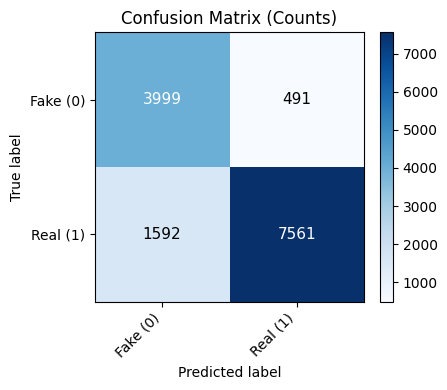

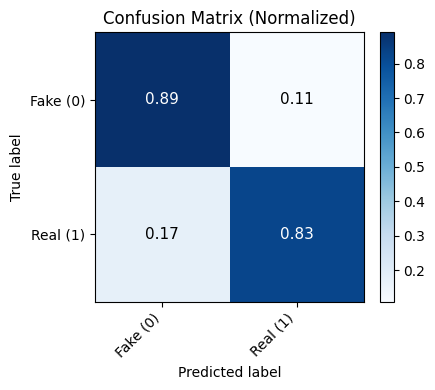

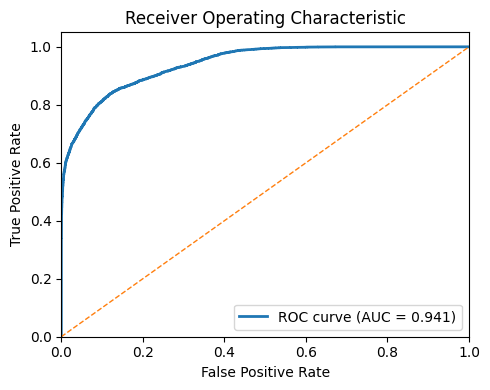

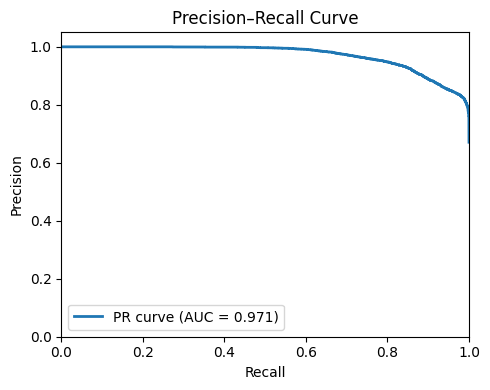

In [ ]:
# ===========================
# Evaluation + Colored Plots
# ===========================
import os, numpy as np, pandas as pd
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, precision_recall_curve, auc)
import matplotlib.pyplot as plt

SPLIT_DIR = f"{BASE}/news_splits"     # where we saved test.csv

# 1) Load exact test set
df_test = pd.read_csv(os.path.join(SPLIT_DIR, "test.csv"))
X_test_texts = df_test["text_full"].astype(str).tolist()
y_test = df_test["label"].astype(int).values

# 2) Predict
X_test_seq = to_seq(X_test_texts)
probs = model.predict(X_test_seq, verbose=0).ravel()
y_pred = (probs >= 0.5).astype(int)

# 3) Metrics
acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec_macro  = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1_macro   = f1_score(y_test, y_pred, average="macro", zero_division=0)
prec_w     = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec_w      = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1_w       = f1_score(y_test, y_pred, average="weighted", zero_division=0)
auc_roc    = roc_auc_score(y_test, probs)

print(f"Accuracy        : {acc:.4f}")
print(f"Precision (macro): {prec_macro:.4f}   | Precision (weighted): {prec_w:.4f}")
print(f"Recall (macro)   : {rec_macro:.4f}    | Recall (weighted)   : {rec_w:.4f}")
print(f"F1-score (macro) : {f1_macro:.4f}     | F1-score (weighted) : {f1_w:.4f}")
print(f"ROC-AUC          : {auc_roc:.4f}\n")

print("Classification report:\n",
      classification_report(y_test, y_pred, digits=4, target_names=["Fake(0)","Real(1)"]))

# 4) Colored Confusion Matrices (counts + normalized)
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
cm_norm = confusion_matrix(y_test, y_pred, labels=[0,1], normalize='true')

def plot_cm(mat, title, fmt=".2f", ticklabels=("Fake (0)","Real (1)")):
    plt.figure(figsize=(5,4))
    im = plt.imshow(mat, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    tick_marks = np.arange(len(ticklabels))
    plt.xticks(tick_marks, ticklabels, rotation=45, ha="right")
    plt.yticks(tick_marks, ticklabels)
    thresh = mat.max() / 2.0
    # annotate cells
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            txt = f"{val}" if fmt == "d" else f"{val:{fmt}}"
            plt.text(j, i, txt, ha="center", va="center",
                     color="white" if val > thresh else "black", fontsize=11)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

# Counts
plot_cm(cm, "Confusion Matrix (Counts)", fmt="d")

# Normalized (per true class)
plot_cm(cm_norm, "Confusion Matrix (Normalized)", fmt=".2f")

# 5) ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", linewidth=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 6) Precision–Recall Curve
prec, rec, _ = precision_recall_curve(y_test, probs)
pr_auc = auc(rec, prec)

plt.figure(figsize=(5,4))
plt.plot(rec, prec, linewidth=2, label=f"PR curve (AUC = {pr_auc:.3f})")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


## evaluating with threshold 0.45

Accuracy        : 0.8544
Precision (macro): 0.8328   | Precision (weighted): 0.8658
Recall (macro)   : 0.8580    | Recall (weighted)   : 0.8544
F1-score (macro) : 0.8417     | F1-score (weighted) : 0.8570
ROC-AUC          : 0.9414

Classification report:
               precision    recall  f1-score   support

     Fake(0)     0.7362    0.8688    0.7970      4490
     Real(1)     0.9294    0.8473    0.8864      9153

    accuracy                         0.8544     13643
   macro avg     0.8328    0.8580    0.8417     13643
weighted avg     0.8658    0.8544    0.8570     13643



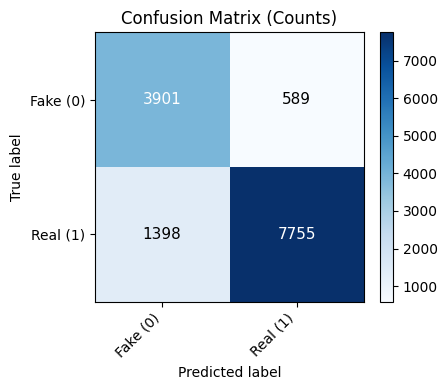

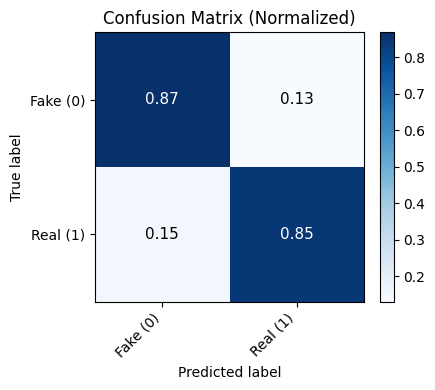

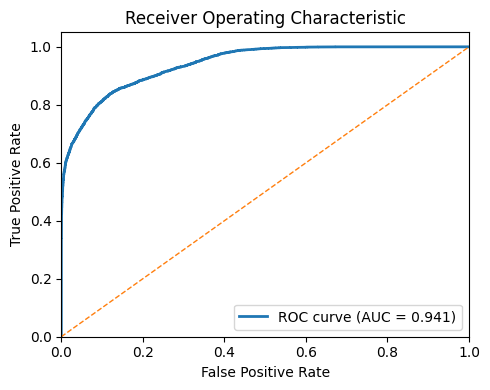

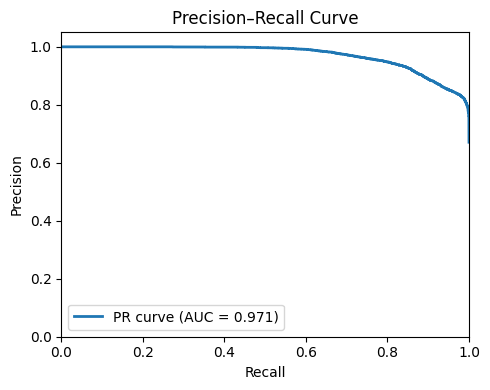

In [ ]:
# ===========================
# Evaluation + Colored Plots
# ===========================
import os, numpy as np, pandas as pd
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, precision_recall_curve, auc)
import matplotlib.pyplot as plt

SPLIT_DIR = f"{BASE}/news_splits"     # where we saved test.csv

# 1) Load exact test set
df_test = pd.read_csv(os.path.join(SPLIT_DIR, "test.csv"))
X_test_texts = df_test["text_full"].astype(str).tolist()
y_test = df_test["label"].astype(int).values

# 2) Predict
X_test_seq = to_seq(X_test_texts)
probs = model.predict(X_test_seq, verbose=0).ravel()
y_pred = (probs >= 0.45).astype(int)

# 3) Metrics
acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec_macro  = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1_macro   = f1_score(y_test, y_pred, average="macro", zero_division=0)
prec_w     = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec_w      = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1_w       = f1_score(y_test, y_pred, average="weighted", zero_division=0)
auc_roc    = roc_auc_score(y_test, probs)

print(f"Accuracy        : {acc:.4f}")
print(f"Precision (macro): {prec_macro:.4f}   | Precision (weighted): {prec_w:.4f}")
print(f"Recall (macro)   : {rec_macro:.4f}    | Recall (weighted)   : {rec_w:.4f}")
print(f"F1-score (macro) : {f1_macro:.4f}     | F1-score (weighted) : {f1_w:.4f}")
print(f"ROC-AUC          : {auc_roc:.4f}\n")

print("Classification report:\n",
      classification_report(y_test, y_pred, digits=4, target_names=["Fake(0)","Real(1)"]))

# 4) Colored Confusion Matrices (counts + normalized)
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
cm_norm = confusion_matrix(y_test, y_pred, labels=[0,1], normalize='true')

def plot_cm(mat, title, fmt=".2f", ticklabels=("Fake (0)","Real (1)")):
    plt.figure(figsize=(5,4))
    im = plt.imshow(mat, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    tick_marks = np.arange(len(ticklabels))
    plt.xticks(tick_marks, ticklabels, rotation=45, ha="right")
    plt.yticks(tick_marks, ticklabels)
    thresh = mat.max() / 2.0
    # annotate cells
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            txt = f"{val}" if fmt == "d" else f"{val:{fmt}}"
            plt.text(j, i, txt, ha="center", va="center",
                     color="white" if val > thresh else "black", fontsize=11)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

# Counts
plot_cm(cm, "Confusion Matrix (Counts)", fmt="d")

# Normalized (per true class)
plot_cm(cm_norm, "Confusion Matrix (Normalized)", fmt=".2f")

# 5) ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", linewidth=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 6) Precision–Recall Curve
prec, rec, _ = precision_recall_curve(y_test, probs)
pr_auc = auc(rec, prec)

plt.figure(figsize=(5,4))
plt.plot(rec, prec, linewidth=2, label=f"PR curve (AUC = {pr_auc:.3f})")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


Validation loss

In [3]:
import os, json, numpy as np, pandas as pd, tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

BASE = "/content/drive/MyDrive"
MODEL_PATH = f"{BASE}/news_models/bilstm_best.keras"
TOK_PATH   = f"{BASE}/news_models/tokenizer.json"
SPLIT_DIR  = f"{BASE}/news_splits"         # first round splits
MAX_LEN = 400

# load model (if it has a Lambda layer, allow unsafe)
import keras
try: keras.config.enable_unsafe_deserialization()
except: pass
model = load_model(MODEL_PATH, safe_mode=False)

# load tokenizer
with open(TOK_PATH, "r", encoding="utf-8") as f:
    tok = tokenizer_from_json(f.read())

def to_seq(texts):
    return pad_sequences(tok.texts_to_sequences(texts), maxlen=MAX_LEN, padding="post", truncating="post")

# load validation split
df_val = pd.read_csv(os.path.join(SPLIT_DIR, "val.csv"))
X_val = to_seq(df_val["text_full"].astype(str).tolist())
y_val = df_val["label"].astype(int).values

# evaluate
results = model.evaluate(X_val, y_val, verbose=0)
print("Metrics order:", model.metrics_names)
print(f"Validation loss: {results[0]:.4f}")


Metrics order: ['loss', 'compile_metrics']
Validation loss: 0.2893
